# Should we increase paid-search spend?

## A marketing-mix analysis under structural uncertainty

A growth team wants to estimate how much additional **qualified sales pipeline**
would be generated by increasing paid-search spend.

The available data are weekly and observational. Marketing managers tended to raise
budgets in weeks when market demand was already strong. Market demand also affects
pipeline directly, so a simple spend-versus-pipeline comparison is confounded.

The additional problem is structural: the data may reveal that spend, demand, and
pipeline are related without uniquely determining every causal direction.

This notebook shows how Antecedent:

1. discovers the observational equivalence class;
2. refuses to invent unsupported edge directions;
3. evaluates identification across compatible DAGs;
4. reports the probability mass where the marketing effect is not identifiable.

The data are **synthetic but operationally realistic**, so the true causal effect is
known and the workflow is fully reproducible.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iridae-dev/antecedent/blob/main/examples/notebooks/marketing_channel_structural_uncertainty.ipynb)

**Repository:** <https://github.com/iridae-dev/antecedent>  
**Documentation:** <https://antecedent.readthedocs.io/>

## Environment: the 1.10 Python API

Use a kernel with the built **1.10.0 branch**, NumPy, pandas and Matplotlib.
See the [local and Colab setup instructions](../README.md#python-environment-110-branch).
These examples use the new API before the 1.10 release; installing an older
published wheel will not provide `prepare`, `load`, or retained studies.


In [1]:
# Use the built 1.10.0 branch (see examples/README.md for local/Colab setup).
import antecedent

if not all(hasattr(antecedent, name) for name in ("prepare", "load")):
    raise RuntimeError(
        "This notebook requires the 1.10 Python API. Build/install the 1.10.0 "
        "branch, then restart the kernel; the older PyPI wheels lack this API."
    )


In [2]:
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import antecedent
from antecedent import AverageEffect, Bayesian, analyze
from antecedent.discovery import ExactDagPosterior

print("antecedent", version("antecedent"))

Matplotlib is building the font cache; this may take a moment.


antecedent 1.9.0


## 2. Simulate weekly marketing operations

The underlying business process is:

$$
\text{market demand}
\rightarrow
\text{paid-search spend}
$$

$$
\text{market demand}
\rightarrow
\text{qualified pipeline}
$$

$$
\text{paid-search spend}
\rightarrow
\text{qualified pipeline}
$$

Variables are expressed in practical units:

- `market_demand_index`: a standardised demand indicator;
- `paid_search_spend_kgbp`: weekly paid-search spend in **£ thousands**;
- `qualified_pipeline_kgbp`: qualified pipeline created in **£ thousands**.

The true incremental effect is **1.5**, meaning that an additional **£1,000**
of paid-search spend generates **£1,500** of qualified pipeline on average.

In [3]:
SEED = 7
N_WEEKS = 2_000
TRUE_PIPELINE_PER_SPEND = 1.5

rng = np.random.default_rng(SEED)

market_demand_index = rng.normal(size=N_WEEKS)

paid_search_spend_kgbp = (
    20.0
    + 4.0 * market_demand_index
    + 5.0 * rng.normal(size=N_WEEKS)
)

qualified_pipeline_kgbp = (
    80.0
    + TRUE_PIPELINE_PER_SPEND * paid_search_spend_kgbp
    + 12.0 * market_demand_index
    + 8.0 * rng.normal(size=N_WEEKS)
)

data = {
    "market_demand_index": market_demand_index,
    "paid_search_spend_kgbp": paid_search_spend_kgbp,
    "qualified_pipeline_kgbp": qualified_pipeline_kgbp,
}
frame = pd.DataFrame(data)

frame.head()

,market_demand_index,paid_search_spend_kgbp,qualified_pipeline_kgbp
0,0.001230,18.176742,113.285584
1,0.298746,22.904040,126.498816
2,-0.274138,18.076739,95.906204
3,-0.890592,11.991470,97.440001
4,-0.454671,22.119723,103.928445


In [4]:
summary = frame.agg(["mean", "std", "min", "max"]).T
summary.round(2)

,mean,std,min,max
market_demand_index,-0.04,0.98,-3.25,2.99
paid_search_spend_kgbp,19.86,6.38,-1.70,41.54
qualified_pipeline_kgbp,109.26,21.05,39.97,177.09


## 3. Why the raw marketing correlation is not the answer

High-demand weeks receive more budget and would have produced more pipeline anyway.
A regression or chart that ignores demand mixes the causal return on spend with this
budget-allocation policy.

Naive observational slope: £2.68k pipeline per £1k spend
True causal effect:         £1.50k pipeline per £1k spend


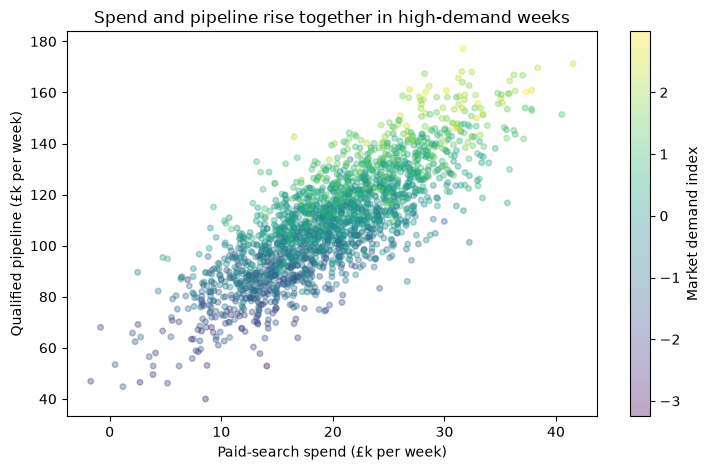

In [5]:
naive_slope = np.polyfit(
    frame["paid_search_spend_kgbp"],
    frame["qualified_pipeline_kgbp"],
    deg=1,
)[0]

print(f"Naive observational slope: £{naive_slope:,.2f}k pipeline per £1k spend")
print(f"True causal effect:         £{TRUE_PIPELINE_PER_SPEND:,.2f}k pipeline per £1k spend")

plt.figure(figsize=(7.5, 4.8))
scatter = plt.scatter(
    frame["paid_search_spend_kgbp"],
    frame["qualified_pipeline_kgbp"],
    c=frame["market_demand_index"],
    alpha=0.35,
    s=16,
)
plt.colorbar(scatter, label="Market demand index")
plt.xlabel("Paid-search spend (£k per week)")
plt.ylabel("Qualified pipeline (£k per week)")
plt.title("Spend and pipeline rise together in high-demand weeks")
plt.tight_layout()
plt.show()

## 4. Discover what the observational data support

PC discovery examines conditional independences. In this linear-Gaussian example,
it recovers the complete three-variable skeleton but cannot orient any edge.

That is not a failure: it is an honest statement that the observational distribution
alone does not select one causal story from the equivalence class.

In [6]:
pc = antecedent.discovery.PC(alpha=0.05).run(data)

print(
    "Edges oriented by PC:",
    f"{pc.cpdag_directed_edges} directed,",
    f"{pc.cpdag_undirected_edges} undirected",
)

Edges oriented by PC: 0 directed, 3 undirected


With this pinned seed and release, the expected result is **0 directed edges and
3 undirected edges**.

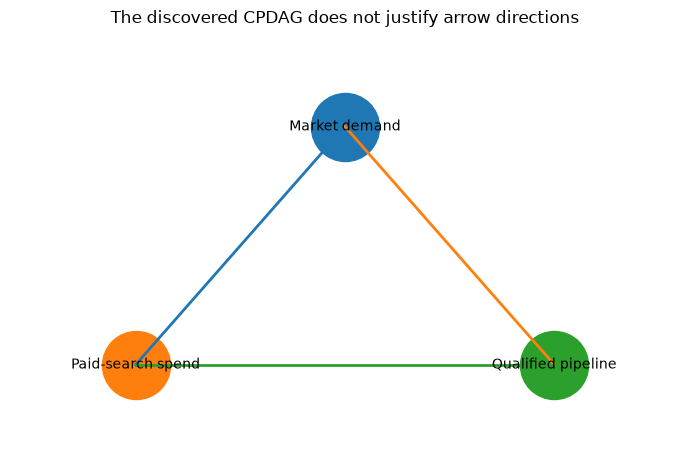

In [7]:
node_positions = {
    "Market demand": (0.0, 1.0),
    "Paid-search spend": (-1.0, 0.0),
    "Qualified pipeline": (1.0, 0.0),
}
undirected_edges = [
    ("Market demand", "Paid-search spend"),
    ("Market demand", "Qualified pipeline"),
    ("Paid-search spend", "Qualified pipeline"),
]

plt.figure(figsize=(7, 4.8))
for left, right in undirected_edges:
    x = [node_positions[left][0], node_positions[right][0]]
    y = [node_positions[left][1], node_positions[right][1]]
    plt.plot(x, y, linewidth=2)

for node, (x, y) in node_positions.items():
    plt.scatter([x], [y], s=2400)
    plt.text(x, y, node, ha="center", va="center", fontsize=10)

plt.title("The discovered CPDAG does not justify arrow directions")
plt.xlim(-1.6, 1.6)
plt.ylim(-0.4, 1.4)
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Ask the business question across compatible structures

The query is the average effect of increasing weekly paid-search spend on qualified
pipeline. `ExactDagPosterior` retains compatible DAGs, and Antecedent checks
identification before estimating the effect in each one.

In [8]:
result = analyze(
    data=data,
    discovery=ExactDagPosterior(),
    query=AverageEffect(
        treatment="paid_search_spend_kgbp",
        outcome="qualified_pipeline_kgbp",
    ),
    inference=Bayesian(n_draws=200, backend="conjugate"),
    seed=SEED,
)

posterior = result.posterior
assert posterior is not None

result

Refuter,Original,Refuted,Comparison,Result
prior_predictive,2.288,-13.587,0.547,pass
posterior_predictive,2.288,109.254,0.978,pass


### Keep the study and inspect the evidence

The analysis call also retains a reusable study. `study.estimate()` uses the
retained data; `study.refresh(new_data)` replaces it after a successful run.
Earlier results remain tied to their own execution. The report includes the
answer shape, identification, uncertainty, assumptions, support and calibration.
`unavailable` calibration means no calibration evidence is bound to this result;
it is not inferred from a passing refutation or an identified graph.


In [9]:
study = result.study
report = result.inspect().to_dict()
print("Answer:", result.answer)
print("Calibration:", result.calibration.status, result.calibration.reason)
report

# Reuse the prepared graph posterior without running discovery again.
repeated = study.estimate()
assert repeated.data_version == result.data_version


Answer: Answer(kind='partial', value=None, bounds=None, detail='unidentified_mass')
Calibration: unavailable No calibration evidence has been bound to this execution.


In [10]:
identification_summary = pd.DataFrame(
    {
        "structural region": [
            "Effect identified",
            "Effect unidentified",
        ],
        "posterior mass": [
            1.0 - posterior.unidentified_mass,
            posterior.unidentified_mass,
        ],
    }
)

identification_summary

,structural region,posterior mass
0,Effect identified,0.5
1,Effect unidentified,0.5


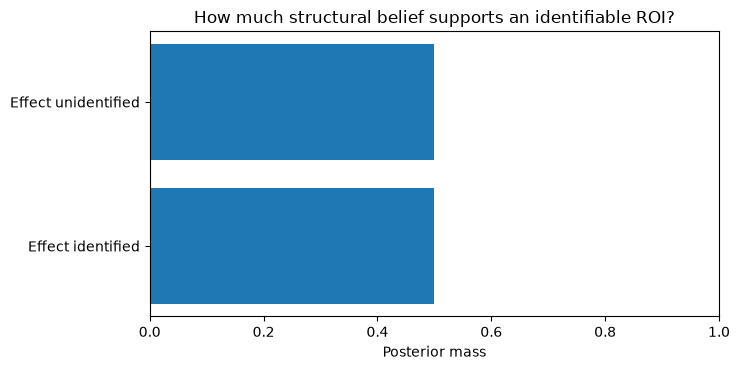

In [11]:
plt.figure(figsize=(7.5, 3.8))
plt.barh(
    identification_summary["structural region"],
    identification_summary["posterior mass"],
)
plt.xlim(0, 1)
plt.xlabel("Posterior mass")
plt.title("How much structural belief supports an identifiable ROI?")
plt.tight_layout()
plt.show()

## 6. Compare with the causal story the marketing team believes

Subject-matter knowledge may justify the intended DAG: current weekly pipeline does
not cause the budget that was already set, and an external demand index precedes both.

Supplying that reviewed graph produces a conditional estimate. This is useful, but it
is a different claim from saying that the graph was uniquely learned from the data.

In [12]:
reviewed_marketing_graph = [
    ("market_demand_index", "paid_search_spend_kgbp"),
    ("market_demand_index", "qualified_pipeline_kgbp"),
    ("paid_search_spend_kgbp", "qualified_pipeline_kgbp"),
]

reviewed_result = analyze(
    data=data,
    graph=reviewed_marketing_graph,
    query=AverageEffect(
        treatment="paid_search_spend_kgbp",
        outcome="qualified_pipeline_kgbp",
    ),
    seed=SEED,
)

reviewed_result

Refuter,Original,Refuted,Comparison,Result
placebo.treatment,1.514,-0.047,0.838,pass
random.common_cause,1.514,1.515,0.830,pass


In [13]:
business_view = pd.DataFrame(
    [
        {
            "analysis": "Naive spend-pipeline slope",
            "effect_per_£1k_spend": naive_slope,
            "structural caveat": "Does not adjust for market demand",
        },
        {
            "analysis": "Reviewed marketing DAG",
            "effect_per_£1k_spend": reviewed_result.answer.value,
            "structural caveat": "Conditional on the supplied causal graph",
        },
        {
            "analysis": "Compatible-graph posterior",
            "effect_per_£1k_spend": posterior.effect_mean,
            "structural caveat": (
                f"{posterior.unidentified_mass:.0%} of structural posterior "
                "does not identify the effect"
            ),
        },
    ]
)

business_view.round(2)

,analysis,effect_per_£1k_spend,structural caveat
0,Naive spend-pipeline slope,2.68,Does not adjust for market demand
1,Reviewed marketing DAG,1.51,Conditional on the supplied causal graph
2,Compatible-graph posterior,2.29,50% of structural posterior does not identify ...


## 7. Decision interpretation

A marketing leader should not read the graph-posterior result as one conventional ROI
estimate with a slightly wider error bar.

There are two distinct uncertainties:

- **effect uncertainty** among causal structures where the effect can be identified;
- **identification uncertainty** from plausible structures where observational data
  do not identify the effect at all.

The analysis suggests concrete next steps:

1. document time ordering and budget-setting policy to rule out implausible directions;
2. add pre-treatment demand measurements;
3. run a geo experiment or budget holdout;
4. update the analysis after those interventions reduce structural ambiguity.

## 8. Reproducibility information

In [14]:
import platform

{
    "python": platform.python_version(),
    "platform": platform.platform(),
    "antecedent": version("antecedent"),
    "seed": SEED,
    "weeks": N_WEEKS,
    "true_pipeline_per_£1k_spend": TRUE_PIPELINE_PER_SPEND,
}

{'python': '3.13.0',
 'platform': 'macOS-26.5.2-arm64-arm-64bit-Mach-O',
 'antecedent': '1.9.0',
 'seed': 7,
 'weeks': 2000,
 'true_pipeline_per_£1k_spend': 1.5}